# ACSEmployment: Data Quality and Geographic Shift

Experiments on 2018 US employment data using Logistic Regression and LightGBM.
Models train on California data and are tested in California and Texas.

Run the cells in order. The full suite takes about eight minutes and writes to
`results_notebook/`. Set `THESIS_RUN_SUITE=0` to use saved results.
Run [Diabetic.ipynb](Diabetic.ipynb) first to regenerate figures using both datasets.


## 0. Setup


In [1]:
import json, os, subprocess, sys, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

ROOT = os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "experiments"))
import common as C

DATA_ROOT = "data"
SEEDS     = C.SEEDS
RUN_SUITE = os.environ.get("THESIS_RUN_SUITE", "1") == "1"
OUT       = os.environ.get("THESIS_NB_RESULTS", "results_notebook")
REFERENCE = "results"
RUN       = f"{OUT}/acs" if RUN_SUITE else f"{REFERENCE}/acs"

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

from IPython.display import Image, display

def show_figure(name):

    local = f"{OUT}/figures/{name}"
    if os.path.exists(local):
        print(f"regenerated by this notebook: {local}")
        display(Image(filename=local))
    else:
        print(f"[reads stored results] thesis_project/figures/{name}")
        display(Image(filename=f"thesis_project/figures/{name}"))

print("seeds:", SEEDS, "| run suite:", RUN_SUITE, "| results read from:", RUN)
print(json.dumps(C.environment_record(), indent=2))

seeds: [42, 43, 44] | run suite: True | results read from: results_notebook/acs
{
  "timestamp": "2026-09-21 18:23:18",
  "python": "3.14.5",
  "platform": "macOS-26.6.2-arm64-arm-64bit-Mach-O",
  "pandas": "3.0.1",
  "numpy": "2.4.3",
  "scikit-learn": "1.8.0",
  "lightgbm": "4.6.0",
  "scipy": "1.17.1",
  "seeds": [
    42,
    43,
    44
  ],
  "argv": [
    "/opt/homebrew/lib/python3.14/site-packages/ipykernel_launcher.py",
    "-f",
    "/private/var/folders/f6/8b2d128x5618wrlbpj9wj1cc0000gn/T/tmp1_cpxfe1.json",
    "--HistoryManager.hist_file=:memory:"
  ],
  "folktables": "0.0.12"
}


## 1. Data and Target

Folktables’ ACSEmployment task uses American Community Survey data (Ding et al., 2021).
The target is `ESR == 1` (civilian employed and at work); all other values are negative.

No age filter is applied, so respondents under 16 enter as negatives. The models therefore
partly learn to identify children. The 16 predictors describe demographic and socioeconomic characteristics.


In [2]:
df_ca, df_tx = C.load_acs(DATA_ROOT)
feat = [c for c in df_ca.columns if c != "y"]
print(f"California  rows {len(df_ca):,}   employed {df_ca.y.mean()*100:.1f}%")
print(f"Texas       rows {len(df_tx):,}   employed {df_tx.y.mean()*100:.1f}%")
print(f"\npredictors ({len(feat)}): {', '.join(feat)}")
print(f"\nnominal codes treated as numeric in the main pipeline ({len(C.ACS_NOMINAL)}): {', '.join(C.ACS_NOMINAL)}")
print(f"respondents under 16: CA {(df_ca.AGEP < 16).mean()*100:.1f}%   TX {(df_tx.AGEP < 16).mean()*100:.1f}%")

California  rows 378,817   employed 45.6%
Texas       rows 268,100   employed 45.2%

predictors (16): AGEP, SCHL, MAR, RELP, DIS, ESP, CIT, MIG, MIL, ANC, NATIVITY, DEAR, DEYE, DREM, SEX, RAC1P

nominal codes treated as numeric in the main pipeline (14): MAR, RELP, DIS, ESP, CIT, MIG, MIL, ANC, NATIVITY, DEAR, DEYE, DREM, SEX, RAC1P
respondents under 16: CA 17.9%   TX 20.1%


In [3]:
pd.concat([df_ca[feat].describe().T[["min", "50%", "max"]].add_prefix("CA "),
           df_tx[feat].describe().T[["min", "50%", "max"]].add_prefix("TX ")], axis=1)

,CA min,CA 50%,CA max,TX min,TX 50%,TX max
AGEP,0.0000,40.0000,94.0000,0.0000,39.0000,92.0000
SCHL,0.0000,18.0000,24.0000,0.0000,16.0000,24.0000
MAR,1.0000,3.0000,5.0000,1.0000,3.0000,5.0000
RELP,0.0000,1.0000,17.0000,0.0000,1.0000,17.0000
DIS,1.0000,2.0000,2.0000,1.0000,2.0000,2.0000
ESP,0.0000,0.0000,8.0000,0.0000,0.0000,8.0000
CIT,1.0000,1.0000,5.0000,1.0000,1.0000,5.0000
MIG,0.0000,1.0000,3.0000,0.0000,1.0000,3.0000
MIL,0.0000,4.0000,4.0000,0.0000,4.0000,4.0000
ANC,1.0000,1.0000,4.0000,1.0000,1.0000,4.0000


## 2. Geographic Shift

California records are split 70/15/15 with target stratification. Texas is the shifted test set.
This evaluates one state pair, so conclusions are limited to that comparison.


In [4]:
P = C.split_acs(df_ca, df_tx, seed=42)
print(pd.DataFrame({k: {"rows": len(v[0]), "employed %": round(v[1].mean()*100, 2)} for k, v in P.items()}).T.to_string())
(Xtr, ytr), (Xte, yte), (Xsh, ysh) = P["train"], P["test"], P["shifted"]

                rows  employed %
train   265,171.0000     45.6200
val      56,823.0000     45.6200
test     56,823.0000     45.6200
shifted 268,100.0000     45.2100


## 3. Preprocessing and Models

All features are treated as numeric and median-imputed, with scaling for Logistic Regression.
Both models use balanced class weights. Section 8 checks one-hot encoding of the 14 nominal codes.

No hyperparameters are tuned, so the validation set is unused.


In [5]:
models = C.build_acs_models(seed=42, pipeline="numeric")
for name, m in models.items():
    clf = m.named_steps["classifier"]
    print(f"{name:<20} {type(clf).__name__}(class_weight={clf.class_weight!r}, random_state={clf.random_state})")
    print("   steps:", " -> ".join(s for s, _ in m.steps))

Logistic Regression  LogisticRegression(class_weight='balanced', random_state=42)
   steps: imputer -> scaler -> classifier
LightGBM             LGBMClassifier(class_weight='balanced', random_state=42)
   steps: imputer -> classifier


## 4. Baseline and Stress-Test Examples

Fit the clean models with seed 42, then inspect the label-noise, missingness and
feature-blanking interventions.


In [6]:
demo = []
for name, m in models.items():
    m.fit(Xtr, ytr)
    for label, Xe, ye in [("In-domain Test", Xte, yte), ("Shifted Test", Xsh, ysh)]:
        p = m.predict_proba(Xe)[:, 1]
        demo.append({"Model": name, "Test Set": label, **C.metrics(ye, p), "mean predicted p": p.mean()})
demo = pd.DataFrame(demo)
print(demo.to_string(index=False))
print("\nobserved employment rate: in-domain %.3f, Texas %.3f" % (yte.mean(), ysh.mean()))

              Model       Test Set  AUROC  AUPRC  Brier Score  mean predicted p
Logistic Regression In-domain Test 0.8451 0.7678       0.1562            0.4823
Logistic Regression   Shifted Test 0.8553 0.7855       0.1507            0.4607
           LightGBM In-domain Test 0.9041 0.8620       0.1235            0.4763
           LightGBM   Shifted Test 0.9109 0.8753       0.1193            0.4545

observed employment rate: in-domain 0.456, Texas 0.452


The clean models are well calibrated. Class weighting has a smaller effect here because the positive rate is close to one half.


In [7]:
ln = [{"noise rate": r, "labels flipped": int((C.label_noise(ytr, r, 42, "acs").to_numpy() != ytr.to_numpy()).sum()),
       "train prevalence": C.label_noise(ytr, r, 42, "acs").mean()} for r in [0.0, 0.05, 0.10, 0.20]]
print("label noise (training labels only, models refit, evaluation labels clean)")
print(pd.DataFrame(ln).to_string(index=False))

label noise (training labels only, models refit, evaluation labels clean)
 noise rate  labels flipped  train prevalence
     0.0000               0            0.4562
     0.0500           13259            0.4601
     0.1000           26517            0.4645
     0.2000           53034            0.4735


At 20% label noise, training prevalence rises from about 45.6% to 47.3%, a smaller change than on Diabetes.


In [8]:
print("columns eligible for masking:", ", ".join(C.ACS_MISSING_COLS), "\n")
rows = []
for label in ["MCAR", "MAR_Age_Older"]:
    for rate in [0.10, 0.20]:
        if label == "MCAR":
            Xn, cols, elig = C.mcar(Xtr, C.ACS_MISSING_COLS, rate, 42, "acs"), C.ACS_MISSING_COLS, len(Xtr)
        else:
            cols = [c for c in C.ACS_MISSING_COLS if c != "AGEP"]
            mask = Xtr["AGEP"] >= 65
            Xn, elig = C.mar(Xtr, cols, rate, mask, 42, "acs"), int(mask.sum())
        rows.append({"mechanism": label, "rate": rate, "columns masked": len(cols),
                     "eligible rows": elig, "cells newly missing": int(Xn[cols].isna().sum().sum())})
print(pd.DataFrame(rows).to_string(index=False))
print("\nAGEP is excluded from the MAR columns: masking the conditioning variable would make the mechanism MNAR.")

columns eligible for masking: AGEP, SCHL, MAR, DIS, CIT, NATIVITY, SEX, RAC1P 

    mechanism   rate  columns masked  eligible rows  cells newly missing
         MCAR 0.1000               8         265171               212136
         MCAR 0.2000               8         265171               424272
MAR_Age_Older 0.1000               7          46533                32571
MAR_Age_Older 0.2000               7          46533                65149

AGEP is excluded from the MAR columns: masking the conditioning variable would make the mechanism MNAR.


In [9]:
for g, cols in C.ACS_FEATURE_GROUPS.items():
    b = C.blank_out(Xte, cols)
    med = Xtr[cols].median().to_dict()
    print(f"{g:<30} columns={cols}")
    print(f"{'':<30} after blanking every row is imputed with the training median {med}")

Education                      columns=['SCHL']
                               after blanking every row is imputed with the training median {'SCHL': 18.0}
Disability                     columns=['DIS', 'DEAR', 'DEYE', 'DREM']
                               after blanking every row is imputed with the training median {'DIS': 2.0, 'DEAR': 2.0, 'DEYE': 2.0, 'DREM': 2.0}
Citizenship_Nativity_Ancestry  columns=['CIT', 'NATIVITY', 'ANC']
                               after blanking every row is imputed with the training median {'CIT': 1.0, 'NATIVITY': 1.0, 'ANC': 1.0}


Blanked features are replaced by their training medians. For example, blanking `DIS`
assigns everyone the code for no disability.

## 5. Run the Full Suite

Run all conditions over three seeds, the one-hot sensitivity analysis and calibration checks.


In [10]:
def run(cmd):
    print("$ " + " ".join(cmd[1:]), flush=True)
    r = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    print("\n".join(r.stdout.strip().splitlines()[-4:]))
    if r.returncode:
        print(r.stderr[-2000:]); raise RuntimeError(f"failed: {' '.join(cmd)}")

if RUN_SUITE:
    P_ = sys.executable
    run([P_, "experiments/run_acs.py", "--pipeline", "numeric", "--out", f"{OUT}/acs"])
    run([P_, "experiments/run_acs.py", "--pipeline", "onehot",
         "--experiments", "baseline,label_noise,feature_shift", "--out", f"{OUT}/acs_onehot"])
    run([P_, "experiments/analyze_predictions.py", "--run", f"{OUT}/acs", "--dataset", "acs"])
    # Combined figures require both datasets.
    run([P_, "experiments/make_figures.py", "--results", OUT, "--out", f"{OUT}/figures"])
else:
    print("THESIS_RUN_SUITE=0: the suite was not run. The sections below read stored results from", REFERENCE)

$ experiments/run_acs.py --pipeline numeric --out results_notebook/acs


   label noise 0.20 done (243s)
   missingness MCAR done (270s)
   missingness MAR_Age_Older done (295s)
DONE results_notebook/acs in 303s; rows=252
$ experiments/run_acs.py --pipeline onehot --experiments baseline,label_noise,feature_shift --out results_notebook/acs_onehot


   label noise 0.05 done (530s)
   label noise 0.10 done (538s)
   label noise 0.20 done (547s)
DONE results_notebook/acs_onehot in 555s; rows=144
$ experiments/analyze_predictions.py --run results_notebook/acs --dataset acs


calibration written: 96 rows
blanking investigation written: 36 rows
$ experiments/make_figures.py --results results_notebook --out results_notebook/figures


wrote fig_blanking_predictions
wrote fig_cross_stressor
wrote fig_missingness_delta
figures done


In [11]:
def load(run_dir, name="raw_results.csv"):
    # Keep "None" as a category label.
    return pd.read_csv(f"{run_dir}/{name}", keep_default_na=False, na_values=[""])

res = load(RUN)
ID, SH, GAP = "In-domain Test", "Shifted Test", "Generalization Gap (Shifted - In-domain)"
print(f"rows: {len(res):,}   seeds: {sorted(res['Random Seed'].unique())}")
print(res.groupby("Experiment").size().to_string())

rows: 252   seeds: [np.int64(42), np.int64(43), np.int64(44)]
Experiment
Baseline          18
Feature Shift     54
Label Noise       72
Missingness      108


## 6. Baseline, Calibration and Label Noise

Tables report means and standard deviations over three seeds. Domain gaps are calculated
within each seed before averaging.


In [12]:
def cell(d, exp, cond, model, tset, metric, **kw):
    q = d[(d.Experiment == exp) & (d.Condition == cond) & (d.Model == model) & (d["Test Set"] == tset)]
    for k, v in kw.items():
        q = q[q[k] == v]
    return q[metric].mean(), q[metric].std()

out = []
for m in C.MODEL_NAMES:
    for met in ["AUROC", "AUPRC", "Brier Score"]:
        r = {"Model": m, "Metric": met}
        for t in [ID, SH, GAP]:
            mu, sd = cell(res, "Baseline", "None", m, t, met)
            r[t] = f"{mu:.3f} ({sd:.3f})"
        out.append(r)
pd.DataFrame(out)

,Model,Metric,In-domain Test,Shifted Test,Generalization Gap (Shifted - In-domain)
0,Logistic Regression,AUROC,0.844 (0.001),0.855 (0.000),0.011 (0.001)
1,Logistic Regression,AUPRC,0.767 (0.001),0.786 (0.000),0.018 (0.001)
2,Logistic Regression,Brier Score,0.156 (0.000),0.151 (0.000),-0.006 (0.000)
3,LightGBM,AUROC,0.904 (0.001),0.911 (0.000),0.007 (0.001)
4,LightGBM,AUPRC,0.862 (0.001),0.875 (0.000),0.013 (0.001)
5,LightGBM,Brier Score,0.124 (0.001),0.119 (0.000),-0.004 (0.001)


Both models have slightly higher AUROC on Texas than on held-out California. A different population is not necessarily a harder prediction task.


In [13]:
cal = pd.read_csv(f"{RUN}/calibration_per_seed.csv")
CALCOLS = ["Brier", "constant_baseline_Brier", "reliability", "resolution", "uncertainty",
           "ECE", "mean_pred", "prevalence"]
cal[cal.Experiment == "Baseline"].groupby(["Model", "Test Set"])[CALCOLS].mean().round(3)

Brier  constant_baseline_Brier  reliability  resolution  uncertainty    ECE  mean_pred  \
Model               Test Set                                                                                                 
LightGBM            In-domain Test 0.1240                   0.2480       0.0010      0.1250       0.2480 0.0200     0.4760   
                    Shifted Test   0.1190                   0.2480       0.0000      0.1280       0.2480 0.0110     0.4550   
Logistic Regression In-domain Test 0.1560                   0.2480       0.0010      0.0920       0.2480 0.0270     0.4830   
                    Shifted Test   0.1510                   0.2480       0.0000      0.0970       0.2480 0.0110     0.4610   

                                    prevalence  
Model               Test Set                    
LightGBM            In-domain Test      0.4560  
                    Shifted Test        0.4520  
Logistic Regression In-domain Test      0.4560  
                    Shifted Test        0.4520

In [14]:
ln_tab = []
for m in C.MODEL_NAMES:
    for rate in [0.05, 0.10, 0.20]:
        r = {"Model": m, "noise": f"{rate:.0%}"}
        for t, lab in [(ID, "ID"), (SH, "SH")]:
            for met in ["AUROC", "Brier Score"]:
                a = res[(res.Experiment == "Label Noise") & (res["Noise Rate"] == rate) &
                        (res.Model == m) & (res["Test Set"] == t)].groupby("Random Seed")[met].mean()
                b = res[(res.Experiment == "Baseline") & (res.Model == m) &
                        (res["Test Set"] == t)].groupby("Random Seed")[met].mean()
                r[f"d{met.split()[0]} {lab}"] = f"{(a-b).mean():+.3f} ({(a-b).std():.3f})"
        ln_tab.append(r)
pd.DataFrame(ln_tab)

,Model,noise,dAUROC ID,dBrier ID,dAUROC SH,dBrier SH
0,Logistic Regression,5%,-0.003 (0.001),+0.003 (0.000),-0.003 (0.000),+0.003 (0.000)
1,Logistic Regression,10%,-0.005 (0.001),+0.007 (0.000),-0.005 (0.000),+0.007 (0.000)
2,Logistic Regression,20%,-0.006 (0.001),+0.019 (0.001),-0.006 (0.000),+0.021 (0.000)
3,LightGBM,5%,-0.001 (0.000),+0.001 (0.000),-0.000 (0.000),+0.001 (0.000)
4,LightGBM,10%,-0.001 (0.000),+0.006 (0.000),-0.001 (0.000),+0.006 (0.000)
5,LightGBM,20%,-0.003 (0.000),+0.022 (0.000),-0.003 (0.000),+0.023 (0.000)


In [15]:
cal[cal.Experiment.isin(["Baseline", "Label Noise"])].groupby(
    ["Model", "Condition", "Test Set"])[
    ["ECE", "Brier", "reliability", "mean_pred", "prevalence", "train_prevalence"]].mean().round(3)

ECE  Brier  reliability  mean_pred  prevalence  train_prevalence
Model               Condition Test Set                                                                          
LightGBM            0% Noise  In-domain Test 0.0200 0.1240       0.0010     0.4760      0.4560            0.4560
                              Shifted Test   0.0110 0.1190       0.0000     0.4550      0.4520            0.4560
                    10% Noise In-domain Test 0.0650 0.1290       0.0060     0.4880      0.4560            0.4560
                              Shifted Test   0.0660 0.1250       0.0060     0.4710      0.4520            0.4560
                    20% Noise In-domain Test 0.1280 0.1450       0.0210     0.4940      0.4560            0.4560
                              Shifted Test   0.1320 0.1420       0.0210     0.4820      0.4520            0.4560
                    5% Noise  In-domain Test 0.0360 0.1250       0.0020     0.4830      0.4560            0.4560
                              Shifted Test   0.0340 0.1210       0.0010     0.4630      0.4520            0.4560
Logistic Regression 0% Noise  In-domain Test 0.0270 0.1560       0.0010     0.4830      0.4560            0.4560
                              Shifted Test   0.0110 0.1510       0.0000     0.4610      0.4520            0.4560
                    10% Noise In-domain Test 0.0570 0.1630       0.0050     0.4910      0.4560            0.4560
                              Shifted Test   0.0600 0.1580       0.0050     0.4740      0.4520            0.4560
                    20% Noise In-domain Test 0.1060 0.1760       0.0170     0.4960      0.4560            0.4560
                              Shifted Test   0.1130 0.1710       0.0170     0.4840      0.4520            0.4560
                    5% Noise  In-domain Test 0.0330 0.1590       0.0020     0.4880      0.4560            0.4560
                              Shifted Test   0.0320 0.1540       0.0010     0.4680      0.4520            0.4560

Label noise changes AUROC only slightly, but expected calibration error rises from
about 0.02 to 0.12. Ranking performance alone would miss this deterioration in probability quality.


regenerated by this notebook: results_notebook/figures/fig_reliability_acs.png


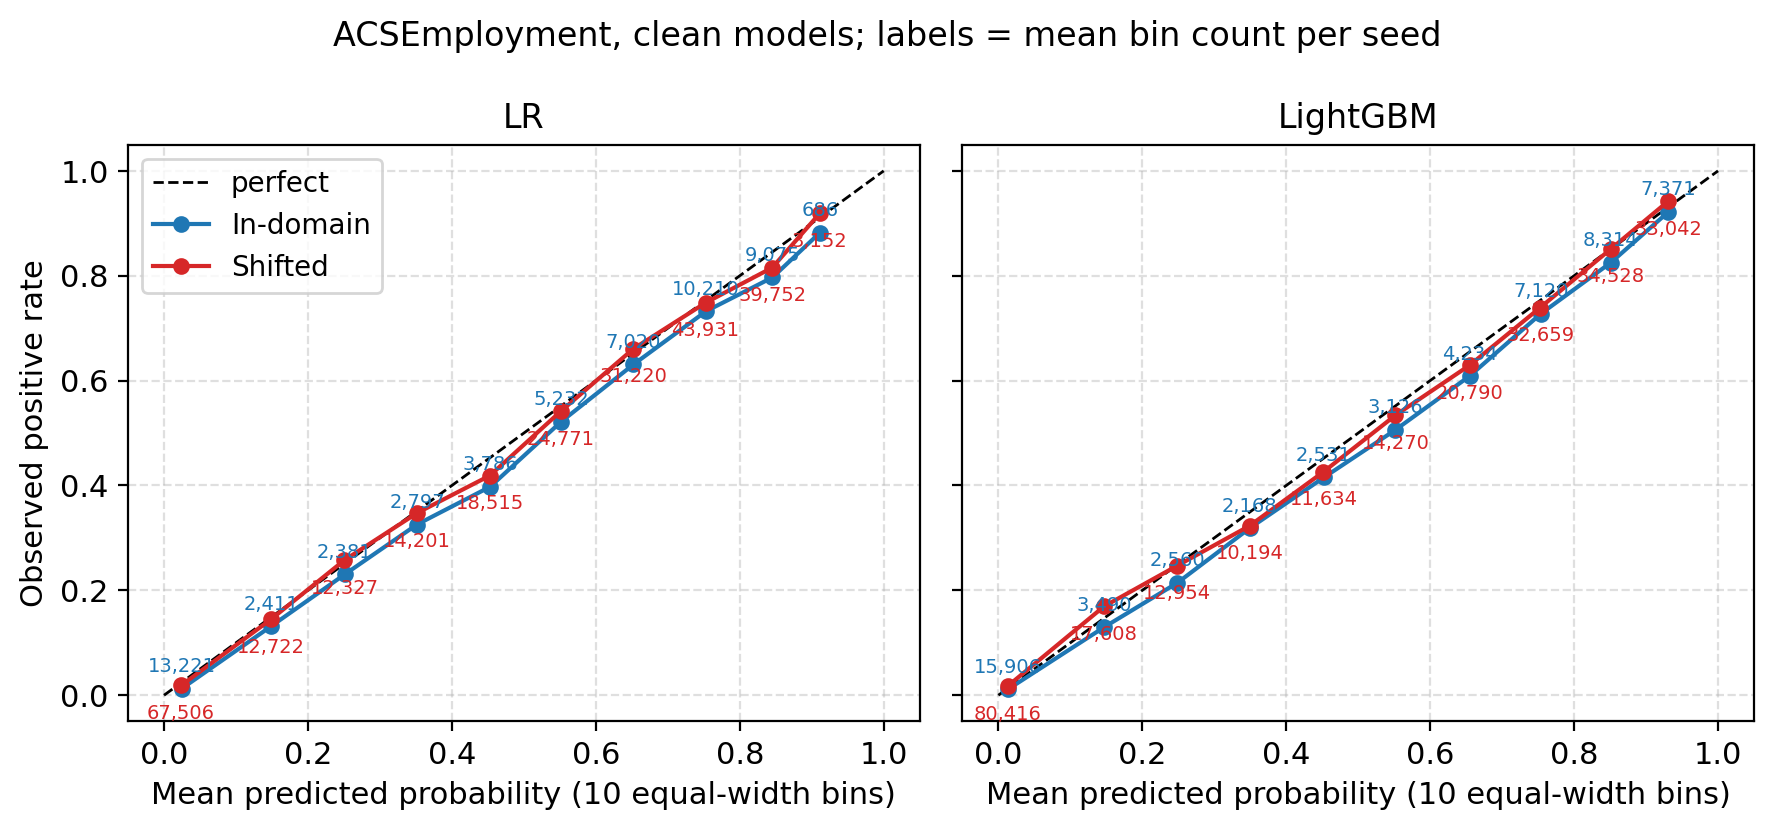

In [16]:
show_figure("fig_reliability_acs.png")

## 7. Missingness and Feature Unavailability

Missingness affects training data, after which models are refitted. Feature blanking affects
both test sets, using the unchanged baseline models.


In [17]:
ms = []
for m in C.MODEL_NAMES:
    for sc in ["MCAR", "MAR_Age_Older"]:
        r = {"Model": m, "mechanism": sc}
        for t, lab in [(ID, "ID"), (SH, "SH")]:
            a = res[(res.Experiment == "Missingness") & (res.Condition == sc) & (res["Missing Rate"] == 0.2) &
                    (res.Model == m) & (res["Test Set"] == t)].groupby("Random Seed")["AUROC"].mean()
            b = res[(res.Experiment == "Baseline") & (res.Model == m) &
                    (res["Test Set"] == t)].groupby("Random Seed")["AUROC"].mean()
            r[f"dAUROC {lab}"] = f"{(a-b).mean():+.4f} ({(a-b).std():.4f})"
        ms.append(r)
pd.DataFrame(ms)

,Model,mechanism,dAUROC ID,dAUROC SH
0,Logistic Regression,MCAR,-0.0011 (0.0003),-0.0017 (0.0001)
1,Logistic Regression,MAR_Age_Older,-0.0003 (0.0001),-0.0000 (0.0000)
2,LightGBM,MCAR,-0.0016 (0.0002),-0.0019 (0.0003)
3,LightGBM,MAR_Age_Older,+0.0001 (0.0001),-0.0001 (0.0001)


In [18]:
fs = []
for m in C.MODEL_NAMES:
    for g in C.ACS_FEATURE_GROUPS:
        r = {"Model": m, "blanked": g}
        for t, lab in [(ID, "ID"), (SH, "SH")]:
            for met in ["AUROC", "Brier Score"]:
                a = res[(res.Experiment == "Feature Shift") & (res.Condition == g) & (res.Model == m) &
                        (res["Test Set"] == t)].groupby("Random Seed")[met].mean()
                b = res[(res.Experiment == "Baseline") & (res.Model == m) &
                        (res["Test Set"] == t)].groupby("Random Seed")[met].mean()
                r[f"d{met.split()[0]} {lab}"] = f"{(a-b).mean():+.3f}"
        fs.append(r)
pd.DataFrame(fs)

,Model,blanked,dAUROC ID,dBrier ID,dAUROC SH,dBrier SH
0,Logistic Regression,Education,-0.008,+0.004,-0.009,+0.004
1,Logistic Regression,Disability,-0.012,+0.010,-0.012,+0.009
2,Logistic Regression,Citizenship_Nativity_Ancestry,-0.001,-0.000,+0.000,+0.000
3,LightGBM,Education,-0.007,+0.004,-0.005,+0.003
4,LightGBM,Disability,-0.010,+0.008,-0.011,+0.008
5,LightGBM,Citizenship_Nativity_Ancestry,-0.003,+0.002,-0.003,+0.002


Training-set missingness changes AUROC by less than about 0.003. Blanking disability features
has the largest feature-removal effect, reducing AUROC by about 0.01.

## 8. Sensitivity to Categorical Encoding

Compare the main numeric pipeline with one-hot encoding of nominal codes.


In [19]:
oh_dir = f"{OUT}/acs_onehot" if RUN_SUITE else f"{REFERENCE}/acs_onehot"
oh = load(oh_dir)
sens = []
for label, d in [("numeric (main)", res), ("one-hot", oh)]:
    for m in C.MODEL_NAMES:
        sens.append({"pipeline": label, "Model": m,
                     "AUROC ID": f"{cell(d,'Baseline','None',m,ID,'AUROC')[0]:.3f}",
                     "AUROC SH": f"{cell(d,'Baseline','None',m,SH,'AUROC')[0]:.3f}",
                     "gap":      f"{cell(d,'Baseline','None',m,GAP,'AUROC')[0]:+.3f}"})
pd.DataFrame(sens)

,pipeline,Model,AUROC ID,AUROC SH,gap
0,numeric (main),Logistic Regression,0.844,0.855,+0.011
1,numeric (main),LightGBM,0.904,0.911,+0.007
2,one-hot,Logistic Regression,0.868,0.879,+0.010
3,one-hot,LightGBM,0.903,0.911,+0.007


One-hot encoding improves Logistic Regression, while LightGBM changes little.
The ordering of the models and the sign of the domain gap remain unchanged.

## 9. Correspondence Between Domains (RQ3)

For each dataset, correlate the in-domain and shifted changes from the clean baseline.
Each observation is a condition–seed pair; clean conditions are excluded from the change analysis.

The calculation uses `common.rq3_correspondence`, shared with the table generator.
The additional maximum-change table is a separate comparison between datasets.


In [20]:
DIAB = f"{OUT}/diabetes" if (RUN_SUITE and os.path.exists(f"{OUT}/diabetes/raw_results.csv")) \
       else f"{REFERENCE}/diabetes"
dg = load(DIAB)
print("Diabetes results read from", DIAB, "\n")

q = pd.concat([C.rq3_correspondence(dg, "Diabetes"), C.rq3_correspondence(res, "ACSEmployment")])
view = q[q.metric.isin(["AUROC", "Brier Score"])][
    ["dataset", "stressor", "model", "metric", "n_obs_delta", "n_distinct_nonclean",
     "spearman_delta", "pearson_delta"]].rename(
    columns={"n_obs_delta": "n", "n_distinct_nonclean": "non-clean cond.",
             "spearman_delta": "rho (ID vs SH)", "pearson_delta": "r (ID vs SH)"})
print(view.round(2).to_string(index=False))

Diabetes results read from results_notebook/diabetes 



      dataset      stressor               model      metric  n  non-clean cond.  rho (ID vs SH)  r (ID vs SH)
     Diabetes   Label Noise Logistic Regression       AUROC  9                3          0.7500        0.8400
     Diabetes   Label Noise Logistic Regression Brier Score  9                3          0.7200        0.7900
     Diabetes   Label Noise            LightGBM       AUROC  9                3          0.5800        0.6300
     Diabetes   Label Noise            LightGBM Brier Score  9                3          0.7200        0.4800
     Diabetes   Missingness Logistic Regression       AUROC 18                6          0.2100        0.2200
     Diabetes   Missingness Logistic Regression Brier Score 18                6          0.6700        0.6700
     Diabetes   Missingness            LightGBM       AUROC 18                6          0.0800        0.0100
     Diabetes   Missingness            LightGBM Brier Score 18                6          0.4000        0.3700
     Diabe

In [21]:
# Supplementary comparison across datasets.
def largest_change(d, exp, metric):
    base = d[d.Experiment == "Baseline"].set_index(["Model", "Random Seed", "Test Set"])[metric]
    e = d[(d.Experiment == exp) & (d["Test Set"].isin([ID, SH]))].copy()
    if exp != "Feature Shift":
        e = e[(e["Noise Rate"].astype(float) > 0) | (e["Missing Rate"].astype(float) > 0)]
    e["delta"] = [r[metric] - base.loc[(r.Model, r["Random Seed"], r["Test Set"])] for _, r in e.iterrows()]
    return e.delta.iloc[e.delta.abs().to_numpy().argmax()]

rows = []
for exp in ["Label Noise", "Missingness", "Feature Shift"]:
    for metric in ["AUROC", "Brier Score"]:
        rows.append({"intervention": exp, "metric": metric,
                     "Diabetes": f"{largest_change(dg, exp, metric):+.3f}",
                     "ACSEmployment": f"{largest_change(res, exp, metric):+.3f}"})
pd.DataFrame(rows)

,intervention,metric,Diabetes,ACSEmployment
0,Label Noise,AUROC,-0.070,-0.007
1,Label Noise,Brier Score,+0.100,+0.023
2,Missingness,AUROC,+0.009,-0.002
3,Missingness,Brier Score,-0.019,+0.001
4,Feature Shift,AUROC,-0.016,-0.012
5,Feature Shift,Brier Score,+0.211,+0.010


regenerated by this notebook: results_notebook/figures/fig_cross_stressor.png


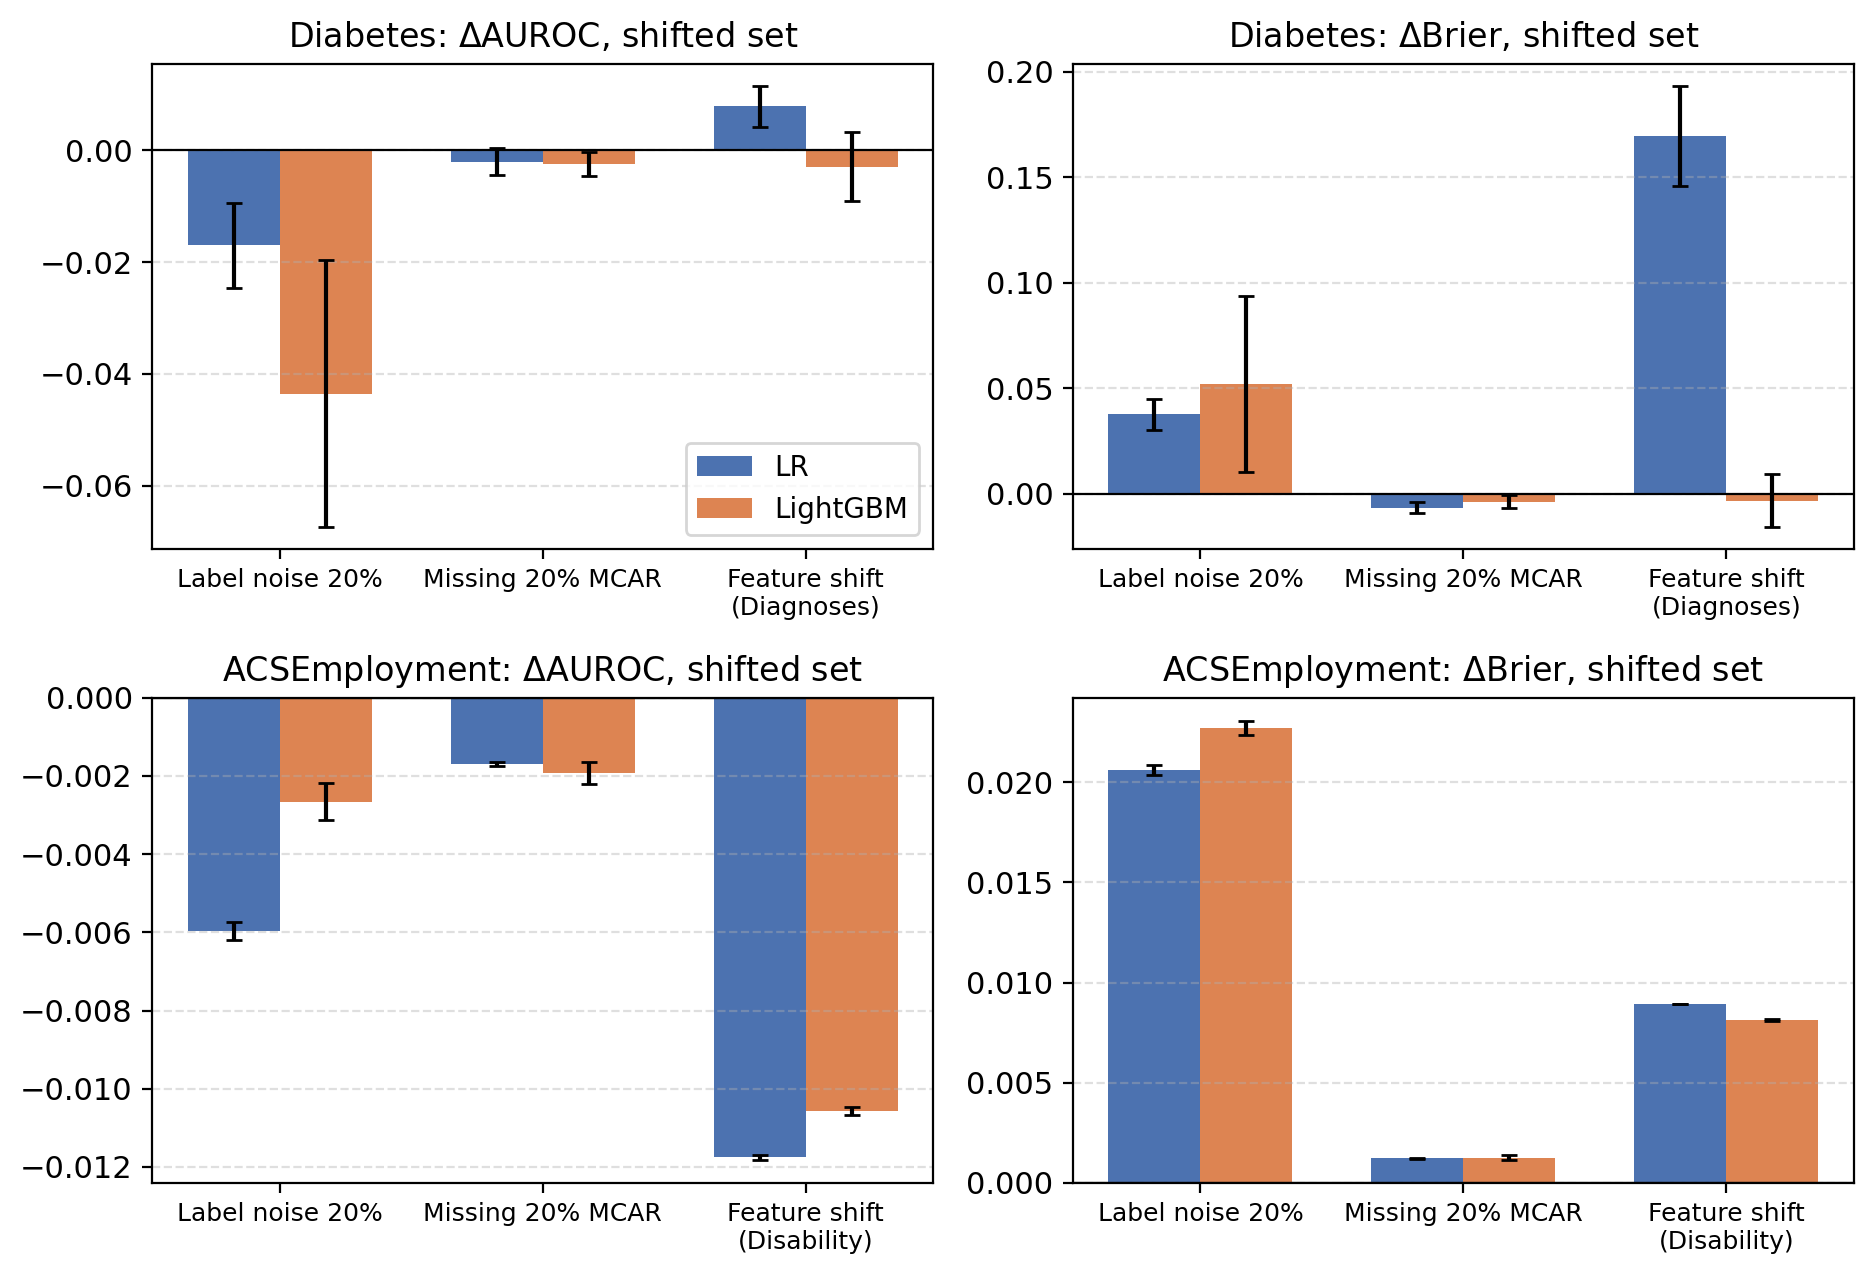

In [22]:
show_figure("fig_cross_stressor.png")

Label-noise responses correspond more closely across domains on ACSEmployment than on Diabetes.
Missingness AUROC correlations are weak on Diabetes (0.21 and 0.08) but strong on
ACSEmployment (0.94 and 0.80), despite small performance changes.

These correlations are descriptive: conditions share doses and seeds, and agreement on
the tested populations does not establish prediction on unseen shifts.

## 10. Verification

Check experiment coverage and agreement with saved results.


In [23]:
print("seeds:", sorted(int(s) for s in res["Random Seed"].unique()), "expected", SEEDS)
KEYS = ["Experiment", "Condition", "Noise Rate", "Missing Rate", "Feature Group Blanked",
        "Model", "Random Seed"]
print("\nconditions per experiment (methods chapter: baseline 1, label noise 4, missingness 6, blanking 3)")
print((res[res["Test Set"] == ID].drop_duplicates(KEYS).groupby("Experiment").size()
       // (len(C.MODEL_NAMES) * len(SEEDS))).to_string())

if RUN_SUITE:
    a = load(RUN).sort_values(list(res.columns)).reset_index(drop=True)
    b = load(f"{REFERENCE}/acs").sort_values(list(res.columns)).reset_index(drop=True)
    num = ["AUROC", "AUPRC", "Brier Score"]
    same = a.shape == b.shape
    worst = float(np.abs(a[num].to_numpy() - b[num].to_numpy()).max()) if same else float("nan")
    print(f"\nrows {a.shape[0]:,} vs {b.shape[0]:,}   identical shape: {same}")
    print(f"largest absolute difference against the submitted results: {worst:.3e}")
    assert same and worst < 1e-12, "this run does not reproduce the submitted results"
    print("PASS: the run reproduces the submitted results exactly")
else:
    print("\n[reads stored results] comparison skipped because the suite was not run")

seeds: [42, 43, 44] expected [42, 43, 44]

conditions per experiment (methods chapter: baseline 1, label noise 4, missingness 6, blanking 3)
Experiment
Baseline         1
Feature Shift    3
Label Noise      4
Missingness      6

rows 252 vs 252   identical shape: True
largest absolute difference against the submitted results: 0.000e+00
PASS: the run reproduces the submitted results exactly


## 11. Main Findings

- Texas is slightly easier for both models than held-out California.
- Label noise mainly damages calibration, with little change in ranking.
- Training-set missingness has small effects at the tested rates.
- Disability-feature removal has the largest feature-blanking effect.

The larger stress-test responses generally correspond across the evaluated domains.
This does not establish predictive validity for other shifts.
